# NFC Relay Attack — Leave-One-Tag-Out (LOTO) Evaluation

Uses the same CNN as CNN_NFC.ipynb but with a proper evaluation protocol.

| | Random split (CNN_NFC.ipynb) | This notebook |
|---|---|---|
| Split | Random stratified 90/10 | **Leave-one-tag-out — 4 folds** |
| Risk | Tag identity leaks into test set | No — test tag never seen in training |
| Expected accuracy | ~99.9% | Unknown — this is what we measure |

**Fold structure:**
Each fold holds out all samples from one physical tag (tag1–tag4) for both normal and wired_relay.
Wireless relay has no per-tag label so it is split proportionally across folds.

```
Fold 1: test  = all tag1_normal + all tag1_wired_relay + 25% wireless_relay
         train = tag2/3/4 normal + tag2/3/4 wired_relay + 75% wireless_relay
Fold 2: test  = tag2 ...
...
```

In [2]:
# ==============================
# Block 1: Imports & reproducibility
# ==============================

import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_fscore_support
)

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'PyTorch: {torch.__version__}')

Device: cuda
PyTorch: 2.11.0+cu128


In [3]:
# ==============================
# Block 2: Load data
# ==============================

# ---- CONFIGURE THIS ----------------------------------------
CSV_PATH = Path('data/nfc_atqa.csv')   # combined CSV
# If using split CSVs instead, set CSV_PATH = None
# ------------------------------------------------------------

FEATURE_COLS = [f'x{i}' for i in range(1800)]
class_names  = ['normal', 'wired_relay', 'wireless_relay']
class_to_idx = {c: i for i, c in enumerate(class_names)}

if CSV_PATH is not None and CSV_PATH.exists():
    df = pd.read_csv(CSV_PATH)
else:
    split_files = sorted(Path('data').glob('nfc_atqa_*.csv'))
    df = pd.concat([pd.read_csv(f) for f in split_files], ignore_index=True)
    print(f'Loaded {len(split_files)} split files')

print(f'Total rows: {len(df):,}')
print(f'\nClass distribution:')
print(df['class'].value_counts())
print(f'\nPhysical tag distribution:')
print(df['physical_tag'].value_counts().sort_index())

X      = df[FEATURE_COLS].to_numpy(dtype=np.float32)
y      = df['class'].map(class_to_idx).to_numpy(dtype=np.int64)
y_str  = df['class'].to_numpy()
groups = df['physical_tag'].to_numpy()

print(f'\nX shape: {X.shape}')

Total rows: 66,366

Class distribution:
class
normal            29496
wired_relay       29496
wireless_relay     7374
Name: count, dtype: int64

Physical tag distribution:
physical_tag
tag1    22122
tag2    14748
tag3    14748
tag4    14748
Name: count, dtype: int64

X shape: (66366, 1800)


In [4]:
# ==============================
# Block 3: LOTO fold builder
# ==============================

PHYSICAL_TAGS = sorted([t for t in np.unique(groups) if t != 'unknown'])
print(f'Physical tags: {PHYSICAL_TAGS}')

def loto_folds(X, y, y_str, groups):
    """Yield (fold_name, train_idx, test_idx) for each physical tag."""
    wireless_mask = (y_str == 'wireless_relay')
    wireless_idx  = np.where(wireless_mask)[0]
    rng           = np.random.default_rng(SEED)
    wireless_idx  = rng.permutation(wireless_idx)

    for k, tag in enumerate(PHYSICAL_TAGS):
        tag_test_mask = (groups == tag) & (~wireless_mask)
        tag_test_idx  = np.where(tag_test_mask)[0]

        w_test_idx  = wireless_idx[k::4]
        w_train_idx = np.concatenate([wireless_idx[j::4] for j in range(4) if j != k])

        test_idx  = np.concatenate([tag_test_idx, w_test_idx])
        train_idx = np.concatenate([
            np.where((groups != tag) & (~wireless_mask))[0],
            w_train_idx
        ])
        yield tag, train_idx, test_idx

# Sanity check
print(f'\n{"Fold":<10} {"Train":>8} {"Test":>8}  Test class dist')
for tag, tr, te in loto_folds(X, y, y_str, groups):
    dist = pd.Series(y_str[te]).value_counts().to_dict()
    print(f'{tag:<10} {len(tr):>8,} {len(te):>8,}  {dist}')

Physical tags: ['tag1', 'tag2', 'tag3', 'tag4']

Fold          Train     Test  Test class dist
tag1         49,774   16,592  {'normal': 7374, 'wired_relay': 7374, 'wireless_relay': 1844}
tag2         49,774   16,592  {'normal': 7374, 'wired_relay': 7374, 'wireless_relay': 1844}
tag3         49,775   16,591  {'normal': 7374, 'wired_relay': 7374, 'wireless_relay': 1843}
tag4         49,775   16,591  {'normal': 7374, 'wired_relay': 7374, 'wireless_relay': 1843}


In [5]:
# ==============================
# Block 4: CNN model — same architecture as CNN_NFC.ipynb
# ==============================

BATCH_SIZE    = 1024   # larger batch suits GPU and 66k dataset
LEARNING_RATE = 1e-3
NUM_EPOCHS    = 100
PATIENCE      = 6


def make_activation(name: str):
    name = name.lower()
    if name == 'relu':      return nn.ReLU()
    if name == 'leakyrelu': return nn.LeakyReLU(negative_slope=0.01)
    if name == 'elu':       return nn.ELU()
    raise ValueError(f'Unknown activation: {name}')


class CNN1DClassifier(nn.Module):
    """Same architecture as CNN_NFC.ipynb."""

    def __init__(self, num_classes=3, activation='relu'):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=7, stride=2, padding=3),
            make_activation(activation),
            nn.BatchNorm1d(16),

            nn.Conv1d(16, 32, kernel_size=5, stride=2, padding=2),
            make_activation(activation),
            nn.BatchNorm1d(32),

            nn.Conv1d(32, 64, kernel_size=5, stride=2, padding=2),
            make_activation(activation),
            nn.BatchNorm1d(64),

            nn.Conv1d(64, 128, kernel_size=3, stride=2, padding=1),
            make_activation(activation),
            nn.BatchNorm1d(128),

            nn.AdaptiveAvgPool1d(1)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            make_activation(activation),
            nn.Dropout(0.20),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))


params = sum(p.numel() for p in CNN1DClassifier().parameters() if p.requires_grad)
print(f'CNN parameters: {params:,}')


def make_optimizer(name, model, lr):
    name = name.lower()
    if name == 'sgd':     return optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    if name == 'adam':    return optim.Adam(model.parameters(), lr=lr)
    if name == 'rmsprop': return optim.RMSprop(model.parameters(), lr=lr, momentum=0.9)
    raise ValueError(f'Unknown optimizer: {name}')

CNN parameters: 46,659


In [6]:
# ==============================
# Block 5: Training helper
# ==============================

def train_loto_fold(X_tr, y_tr, X_te, y_te, fold_name,
                    optimizer_name='adam', activation='relu'):

    # Scale: fit on train only
    scaler   = StandardScaler()
    X_tr_s   = scaler.fit_transform(X_tr).astype(np.float32)
    X_te_s   = scaler.transform(X_te).astype(np.float32)

    # Conv1d expects [batch, 1, length]
    X_tr_t = torch.tensor(X_tr_s).unsqueeze(1)
    X_te_t = torch.tensor(X_te_s).unsqueeze(1)
    y_tr_t = torch.tensor(y_tr, dtype=torch.long)
    y_te_t = torch.tensor(y_te, dtype=torch.long)

    train_loader = DataLoader(
        TensorDataset(X_tr_t, y_tr_t),
        batch_size=BATCH_SIZE, shuffle=True
    )

    model     = CNN1DClassifier(num_classes=3, activation=activation).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = make_optimizer(optimizer_name, model, LEARNING_RATE)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

    best_loss    = float('inf')
    best_state   = None
    patience_ctr = 0
    train_losses = []

    for epoch in range(NUM_EPOCHS):
        model.train()
        running = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            running += loss.item() * xb.size(0)

        epoch_loss = running / len(train_loader.dataset)
        train_losses.append(epoch_loss)
        scheduler.step(epoch_loss)

        if epoch_loss < best_loss:
            best_loss    = epoch_loss
            best_state   = {k: v.clone() for k, v in model.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1
            if patience_ctr >= PATIENCE:
                print(f'    Early stop at epoch {epoch+1}')
                break

        if (epoch + 1) % 10 == 0:
            print(f'    Epoch {epoch+1:3d} | loss={epoch_loss:.5f}')

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        logits = model(X_te_t.to(device))
        y_pred = torch.argmax(logits, dim=1).cpu().numpy()

    acc = accuracy_score(y_te, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_te, y_pred, average='macro', zero_division=0
    )
    print(f'  [{fold_name}] acc={acc:.4f}  f1={f1:.4f}')
    return y_pred, acc, f1, train_losses

In [7]:
# ==============================
# Block 6: Run LOTO folds
# ==============================
#
# Uses the best config from CNN_NFC.ipynb: adam + relu
# Change OPTIMIZER / ACTIVATION below to test others.

OPTIMIZER  = 'adam'
ACTIVATION = 'relu'

fold_results  = []
all_true      = []
all_pred      = []

for fold_tag, train_idx, test_idx in loto_folds(X, y, y_str, groups):
    print(f'\n{"="*55}')
    print(f'FOLD: hold-out tag = {fold_tag}  '
          f'(train={len(train_idx):,}  test={len(test_idx):,})')
    print('='*55)

    X_tr, X_te = X[train_idx], X[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    y_pred, acc, f1, losses = train_loto_fold(
        X_tr, y_tr, X_te, y_te, fold_tag,
        optimizer_name=OPTIMIZER,
        activation=ACTIVATION
    )

    report = classification_report(
        y_te, y_pred, target_names=class_names, output_dict=True, zero_division=0
    )
    fold_results.append({
        'fold':          fold_tag,
        'accuracy':      acc,
        'macro_f1':      f1,
        **{f'{c}_f1': report[c]['f1-score'] for c in class_names}
    })
    all_true.extend(y_te)
    all_pred.extend(y_pred)

print(f'\n{"="*55}')
print('ALL FOLDS COMPLETE')
print('='*55)


FOLD: hold-out tag = tag1  (train=49,774  test=16,592)
    Epoch  10 | loss=0.00250
    Epoch  20 | loss=0.00014
    Epoch  30 | loss=0.00008
    Epoch  40 | loss=0.00004
    Epoch  50 | loss=0.00003
    Early stop at epoch 56
  [tag1] acc=0.5508  f1=0.5540

FOLD: hold-out tag = tag2  (train=49,774  test=16,592)
    Epoch  10 | loss=0.00064
    Epoch  20 | loss=0.00011
    Epoch  30 | loss=0.00004
    Epoch  40 | loss=0.00186
    Early stop at epoch 42
  [tag2] acc=0.5555  f1=0.4360

FOLD: hold-out tag = tag3  (train=49,775  test=16,591)
    Epoch  10 | loss=0.00222
    Epoch  20 | loss=0.00129
    Early stop at epoch 22
  [tag3] acc=0.9838  f1=0.9712

FOLD: hold-out tag = tag4  (train=49,775  test=16,591)
    Epoch  10 | loss=0.00057
    Epoch  20 | loss=0.00040
    Epoch  30 | loss=0.00016
    Epoch  40 | loss=0.00011
    Epoch  50 | loss=0.00006
    Epoch  60 | loss=0.00006
    Epoch  70 | loss=0.00004
    Epoch  80 | loss=0.00005
    Early stop at epoch 82
  [tag4] acc=0.5193  f1=

In [8]:
# ==============================
# Block 7: Summary
# ==============================

results_df = pd.DataFrame(fold_results)

print('\nPer-fold results:')
print(results_df.to_string(index=False))

print(f'\nLOTO summary (mean ± std across {len(PHYSICAL_TAGS)} folds):')
numeric = results_df.drop(columns=['fold'])
print(f'  accuracy  : {numeric["accuracy"].mean():.4f} ± {numeric["accuracy"].std():.4f}')
print(f'  macro_f1  : {numeric["macro_f1"].mean():.4f} ± {numeric["macro_f1"].std():.4f}')
for c in class_names:
    col = f'{c}_f1'
    print(f'  {col:<30}: {numeric[col].mean():.4f} ± {numeric[col].std():.4f}')

# Compare to random split
print(f'\nComparison:')
print(f'  Random split accuracy (CNN_NFC.ipynb) : ~0.9999  (adam+relu)')
print(f'  LOTO accuracy (this notebook)         : {numeric["accuracy"].mean():.4f}')
gap = 0.9999 - numeric['accuracy'].mean()
if gap > 0.05:
    print(f'  Gap: {gap:.4f} — random split was inflated by tag identity leakage')
elif gap > 0.01:
    print(f'  Gap: {gap:.4f} — some inflation from random split')
else:
    print(f'  Gap: {gap:.4f} — model genuinely generalizes to unseen tags')


Per-fold results:
fold  accuracy  macro_f1  normal_f1  wired_relay_f1  wireless_relay_f1
tag1  0.550808  0.553963   0.661888        0.000000           1.000000
tag2  0.555509  0.435969   0.787652        0.000000           0.520254
tag3  0.983847  0.971216   1.000000        0.981497           0.932152
tag4  0.519257  0.437459   0.927175        0.038341           0.346860

LOTO summary (mean ± std across 4 folds):
  accuracy  : 0.6524 ± 0.2216
  macro_f1  : 0.5997 ± 0.2538
  normal_f1                     : 0.8442 ± 0.1501
  wired_relay_f1                : 0.2550 ± 0.4847
  wireless_relay_f1             : 0.6998 ± 0.3167

Comparison:
  Random split accuracy (CNN_NFC.ipynb) : ~0.9999  (adam+relu)
  LOTO accuracy (this notebook)         : 0.6524
  Gap: 0.3475 — random split was inflated by tag identity leakage


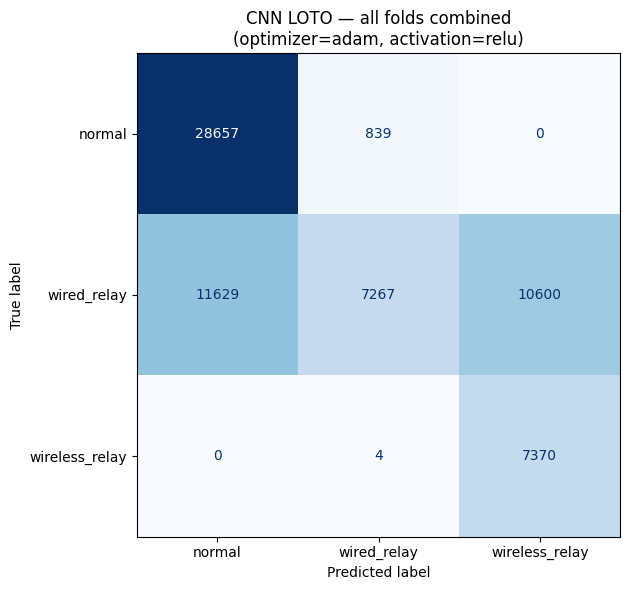

Saved: loto_confusion_matrix.png


In [9]:
# ==============================
# Block 8: Confusion matrix
# ==============================

cm = confusion_matrix(all_true, all_pred)
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
    ax=ax, colorbar=False, cmap='Blues'
)
ax.set_title(
    f'CNN LOTO — all folds combined\n'
    f'(optimizer={OPTIMIZER}, activation={ACTIVATION})'
)
plt.tight_layout()
plt.savefig('loto_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: loto_confusion_matrix.png')

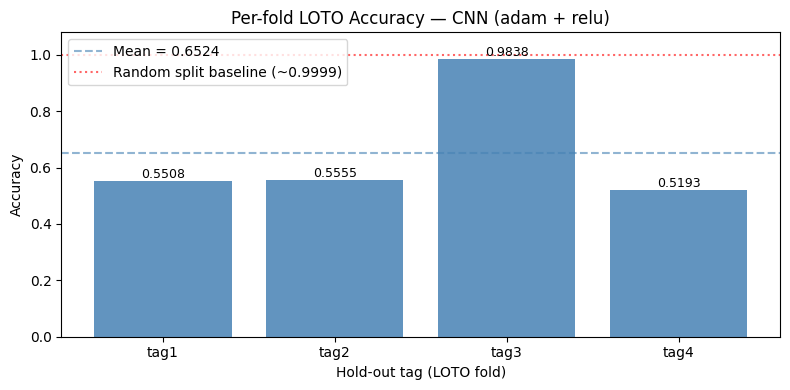

Saved: loto_per_fold_accuracy.png


In [10]:
# ==============================
# Block 9: Per-fold accuracy bar chart
# ==============================

fig, ax = plt.subplots(figsize=(8, 4))
folds = results_df['fold'].tolist()
accs  = results_df['accuracy'].tolist()
bars  = ax.bar(folds, accs, color='steelblue', alpha=0.85)
ax.axhline(np.mean(accs), color='steelblue', linestyle='--',
           alpha=0.6, label=f'Mean = {np.mean(accs):.4f}')
ax.axhline(0.9999, color='red', linestyle=':', alpha=0.6,
           label='Random split baseline (~0.9999)')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)
ax.set_xlabel('Hold-out tag (LOTO fold)')
ax.set_ylabel('Accuracy')
ax.set_title('Per-fold LOTO Accuracy — CNN (adam + relu)')
ax.set_ylim(0, 1.08)
ax.legend()
plt.tight_layout()
plt.savefig('loto_per_fold_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: loto_per_fold_accuracy.png')

In [11]:
# ==============================
# Block 10: Save results
# ==============================

results_df.to_csv('loto_cnn_results.csv', index=False)
print('Saved: loto_cnn_results.csv')
print('\nDone.')

Saved: loto_cnn_results.csv

Done.
